In [1]:
from configs.datasets.real import *
from data.datasets.real import *

In [13]:
info = {
    dataset.dataset_name:{
        "n_points": int(dataset.get_splits().train.x.shape[0] / 0.6),
        "x_dim": dataset.x_dim,
        "y_dim": dataset.y_dim,
    }
    for dataset in 
    (
        SGEMMDataset(config=SGEMMDatasetConfig()),
        BioDataset(config=BioDatasetConfig()),
        BlogDataset(config=BlogDatasetConfig()),
        ATP1dDataset(config=ATP1dDatasetConfig()),
        ATP7dDataset(config=ATP7dDatasetConfig()),
        RF1Dataset(config=RF1DatasetConfig()),
        RF2Dataset(config=RF2DatasetConfig()),
        QM9Dataset(config=QM9DatasetConfig()),
    )
}

In [14]:
for key, item in info.items():
    print(f"{key}")
    for c, v in item.items():
        print(f'\t{c}: {v}')
    print("\n")

SGEMM
	n_points: 241600
	x_dim: 14
	y_dim: 4


Bio
	n_points: 45730
	x_dim: 8
	y_dim: 2


Blog
	n_points: 52396
	x_dim: 279
	y_dim: 2


ATP1D
	n_points: 336
	x_dim: 411
	y_dim: 6


ATP7D
	n_points: 295
	x_dim: 411
	y_dim: 6


RF1
	n_points: 9125
	x_dim: 64
	y_dim: 8


RF2
	n_points: 9125
	x_dim: 576
	y_dim: 8


QM9
	n_points: 130830
	x_dim: 100
	y_dim: 4




In [32]:
train_split = SGEMMDataset(config=SGEMMDatasetConfig()).get_splits().train
test_split = SGEMMDataset(config=SGEMMDatasetConfig()).get_splits().test
calibration_split = SGEMMDataset(config=SGEMMDatasetConfig()).get_splits().calibration

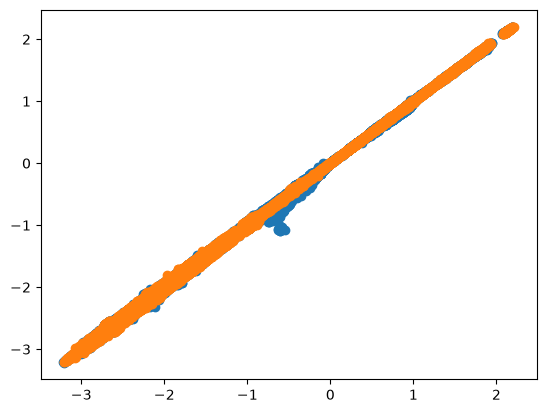

In [36]:
import matplotlib.pyplot as plt
import torch

scaled_train = train_split.y / train_split.y.std(dim=0, keepdim=True)
log_scaled_train = torch.log(scaled_train)
# non_zero_train = scaled_train[(~torch.isinf(torch.log(scaled_train)[:, 0]) * ~torch.isinf(torch.log(scaled_train)[:, 1]))]

plt.scatter((log_scaled_train)[:, 0], (log_scaled_train)[:, 1])
plt.scatter((log_scaled_train)[:, 2], (log_scaled_train)[:, 3])
plt.show()

# plt.scatter(train_split.y[mask, 0], train_split.y[mask, 1])

In [47]:
mask = (train_split.y[:, 1] < 46) * (train_split.y[:, 0] < 7500)

In [50]:
mask.sum() / train_split.y[:, 0].shape[0]

tensor(0.9797)

In [ ]:
100 * (1. - train_split.y[
    train_split.y[:, 1] > 46
, 1].shape[0] / train_split.y[:, 0].shape[0])

98.91755958889132

In [25]:
100 * (1. - (train_split.y[:, 0] > 7500).sum() / train_split.y[:, 0].shape[0])

tensor(99.0415)